In [9]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

import optuna
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [10]:
def str2num(txt):
    try:
        txt = re.sub('[^0-9,]', '', txt)
        txt = re.sub(',', '.', txt)
        return float(txt)
    except TypeError:
        return np.nan


def split_adress(row):
    txt = re.sub('На карте', '', row['Адрес'])
    words = txt.split(', ')
    if len(words) == 4:
        try:
            num = re.findall(r'^\d+', words[3])[0]
            letter = words[3][len(num):]
            return words[0], words[1], None, words[2], int(num), letter
        except:
            return words[0], words[1], words[2], words[3], np.nan, ''
    if len(words) == 5:
        num = re.findall(r'^\d+', words[4])[0]
        letter = words[4][len(num):]
        return words[0], words[1], words[2], words[3], int(num), letter
    if len(words) == 6:
        num = re.findall(r'^\d+', words[5])[0]
        letter = words[5][len(num):]
        return words[0], words[1], words[2], ', '.join([words[3], words[4]]), int(num), letter


train = pd.read_csv('cian_train.csv', index_col=0)

train['Цена'] = train['Цена'].apply(lambda x: str2num(x))
train['Общая площадь'] = train['Общая площадь'].apply(lambda x: str2num(x))
train['Площадь кухни'] = train['Площадь кухни'].apply(lambda x: str2num(x))
train['Высота потолков'] = train['Высота потолков'].apply(lambda x: str2num(x))
train['Жилая площадь'] = train['Жилая площадь'].apply(lambda x: str2num(x))

train['Этаж'] = train['Этаж'].apply(lambda x: int(x.split()[0]))

def get_first_num(txt):
    txt = re.sub('[^0-9]', ' ', txt)
    txt = re.sub('\+ ', ' ', txt)
    txt = txt.strip()
    num = int(txt.split(' ')[0])
    if num > 10:
        num = 1
    return num

train['Количество комнат'] = train['Имя'].apply(lambda x: get_first_num(x))

train[['Область', 'Город', 'Район', 'Улица', 'Номер дома', 'Корпус']] = train.apply(split_adress, axis=1, result_type="expand")

train['Санузел'].fillna('Не указано', inplace=True)
train['Вид из окон'].fillna('Не указано', inplace=True)
train['Ремонт'].fillna('Не указано', inplace=True)
train['Строительная серия'].fillna('Не указано', inplace=True)
train['Тип дома'].fillna('Не указано', inplace=True)
train['Тип перекрытий'].fillna('Не указано', inplace=True)
train['Отопление'].fillna('Не указано', inplace=True)
train['Аварийность'].fillna('Не указано', inplace=True)
train['Парковка'].fillna('Не указано', inplace=True)
train['Балкон/лоджия'].fillna('Не указано', inplace=True)
train['Район'].fillna('Не указано', inplace=True)

print(train.isna().sum())

train

Имя                      0
Ссылка                   0
Цена                     0
Адрес                    0
Описание                 0
Общая площадь            0
Площадь кухни           69
Этаж                     0
Год постройки           32
Тип жилья                0
Высота потолков        331
Санузел                  0
Вид из окон              0
Ремонт                   0
Строительная серия       0
Тип дома                 0
Тип перекрытий           0
Подъезды                51
Отопление                0
Аварийность              0
Обременения            417
Кадастровый номер      417
Площадь                417
Тип помещения          417
Парковка                 0
Собственников          419
Жилая площадь          371
Мусоропровод           431
Продаётся с мебелью    430
Балкон/лоджия            0
Количество лифтов      413
Газоснабжение          482
Размер доли            486
Количество комнат        0
Область                  0
Город                    0
Район                    0
У

C:\Users\Dalabis\AppData\Local\Temp\ipykernel_2308\443093673.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Санузел'].fillna('Не указано', inplace=True)
C:\Users\Dalabis\AppData\Local\Temp\ipykernel_2308\443093673.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

,Имя,Ссылка,Цена,Адрес,Описание,Общая площадь,Площадь кухни,Этаж,Год постройки,Тип жилья,...,Количество лифтов,Газоснабжение,Размер доли,Количество комнат,Область,Город,Район,Улица,Номер дома,Корпус
0,"2-комн. квартира, 45,9 м², 1/2 этаж",https://kemerovo.cian.ru/sale/flat/309364361/,1600000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Продаётся 2-комнатная квартира. Есть вся необх...,45.9,5.0,1,1958.0,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Центральный,Союзная ул.,22.0,
1,"2-комн. квартира, 43,4 м², 1/5 этаж",https://kemerovo.cian.ru/sale/flat/305564238/,3300000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Продам квартиру, комнаты изолированные. 1 этаж...",43.4,5.3,1,1972.0,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Обручева,17.0,
2,просторная 4к с большой прихожей,https://kemerovo.cian.ru/sale/flat/300926183/,5500000.0,"Кемеровская область, Прокопьевск, р-н Централь...","Прeдлагаем к пpoдаже простoрную,cветлую и тeп...",86.0,8.9,2,1982.0,Вторичка,...,NaN,NaN,NaN,4,Кемеровская область,Прокопьевск,р-н Центральный,Союзная ул.,67.0,
3,"1-комн. квартира, 26 м², 3/3 этаж",https://kemerovo.cian.ru/sale/flat/314127343/,1350000.0,"Кемеровская область, Прокопьевск, р-н Зенковск...","Продается квартира в Зенковском районе,Красный...",26.0,6.0,3,1963.0,Вторичка,...,NaN,NaN,NaN,1,Кемеровская область,Прокопьевск,р-н Зенковский,ул. Черных,20.0,
4,2-к. квартира у Школы 71,https://kemerovo.cian.ru/sale/flat/310728535/,1850000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Собственник. Торг. Продаётся уютная 2-к кварти...,41.5,5.6,2,NaN,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Центральный,Ясная Поляна микрорайон,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,"4-комн. квартира, 82,4 м², 7/9 этаж",https://kemerovo.cian.ru/sale/flat/313806030/,6500000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Светлая,очень теплая.Рядом 32 школа, детсад, ф...",82.4,9.0,7,2000.0,Вторичка,...,1 пассажирский,NaN,NaN,4,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Гайдара,18.0,
483,"4-комн. квартира, 89 м², 2/9 этаж",https://kemerovo.cian.ru/sale/flat/314089119/,7000000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Продам 4х комнатную мебелированную квартиру. П...,89.0,9.0,2,1984.0,Вторичка,...,1 пассажирский,NaN,NaN,4,Кемеровская область,Прокопьевск,р-н Рудничный,просп. Строителей,27.0,
484,"4-комн. квартира, 90 м², 10/10 этаж",https://kemerovo.cian.ru/sale/flat/314168362/,9800000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",продам уютную теплую квартиру. с капитальным р...,90.0,9.0,10,NaN,Вторичка,...,1 пассажирский,NaN,NaN,4,Кемеровская область,Прокопьевск,р-н Рудничный,"Тырган микрорайон, 10-й микрорайон",11.0,
485,"3-комн. квартира, 63 м², 3/5 этаж",https://kemerovo.cian.ru/sale/flat/313213754/,4400000.0,"Кемеровская область, Топки, Солнечный микрорай...",Арт. 91066390 Просторная 3-комнатная квартира ...,63.0,9.5,3,1987.0,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Топки,Не указано,Солнечный микрорайон,4.0,Б


In [11]:
target = 'Цена'
num_columns = [
    # 'Жилая площадь', 'Собственников'
    'Общая площадь', 'Площадь кухни', 'Этаж', 'Высота потолков', 'Год постройки', 'Номер дома', 'Подъезды', 'Количество комнат'
]
cat_columns = [
    # 'Тип жилья', 'Парковка', 'Аварийность', 'Отопление'
    'Санузел', 'Вид из окон', 'Ремонт', 'Строительная серия', 'Тип дома', 'Тип перекрытий', 'Балкон/лоджия', 'Район'
]

In [12]:
X = train[num_columns + cat_columns]
y = train[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
class TargetMeanEncoder:
    def __init__(self):
        self.maps = dict()
    
    def fit(self, df, y, col):
        df_target = df.copy(deep=True)
        df_target['target'] = y
        self.maps[col] = df_target.groupby(col)['target'].mean().to_dict()

    def transform(self, df, col):
        df['%s_target_mean' % col] = df[col].map(self.maps[col])
        return df

    def fit_transform(self, df, y, col):
        self.fit(df, y, col)
        return self.transform(df, col)


encoder = TargetMeanEncoder()

for col in cat_columns:
    X_train = encoder.fit_transform(X_train, y_train, col)
    X_test = encoder.transform(X_test, col)

cat_target_mean_columns = [col for col in X_train.columns if '_target_mean' in col]

In [18]:
selected_features = num_columns + cat_target_mean_columns

In [19]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((389, 16), (98, 16), (389,), (98,))

In [ ]:
def objective(trial, X_train, y_train, X_val, y_val):
    """
    Objective function to optimize.
    Returns validation accuracy.
    """
    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'gamma': trial.suggest_float('gamma', 0.01, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'fcluster_threshold': trial.suggest_float('fcluster_threshold', 0.01, 0.99)
    }

    correlation_matrix = X_train[selected_features].corr()
    correlation_matrix = np.abs(correlation_matrix)

    dissimilarity = 1 - abs(correlation_matrix.values)
    Z = linkage(squareform(dissimilarity), 'complete')

    clusters = fcluster(Z, t=params['fcluster_threshold'], criterion='distance')

    fuatures = dict()
    for cls in set(clusters):
        best_corr = -1
        feature = ""
        for i in range(len(clusters)):
            if clusters[i] == cls:
                if correlation_matrix.values[i, -1] > best_corr:
                    best_corr = np.abs(correlation_matrix.values[i, -1])
                    feature = selected_features[i]
        fuatures[feature] = best_corr
        # print(cls, feature, best_corr)
    fuatures = dict(sorted(fuatures.items(), key=lambda item: item[1], reverse=True))

    X_train = X_train[fuatures.keys()]
    X_val = X_val[fuatures.keys()]
    
    # Train model
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # Predict and evaluate
    predictions = model.predict(X_val)
    accuracy = root_mean_squared_error(y_val, predictions)
    
    return accuracy

def tune_xgboost(X_train, y_train, X_test, y_test):
    """
    Main function to perform hyperparameter tuning using Optuna.
    Returns best parameters and trained model.
    """
    # Split training data into training and validation sets
    X_train_opt, X_val, y_train_opt, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )
    
    # Perform optimization
    study = optuna.create_study(direction='minimize')
    n_trials = 10000
    
    study.optimize(lambda trial: objective(trial, X_train_opt, y_train_opt, X_val, y_val), n_trials=n_trials)
    
    # Train final model with best parameters
    best_params = study.best_trial.params

    correlation_matrix = X_train[selected_features].corr()
    correlation_matrix = np.abs(correlation_matrix)

    dissimilarity = 1 - abs(correlation_matrix.values)
    Z = linkage(squareform(dissimilarity), 'complete')

    clusters = fcluster(Z, t=best_params['fcluster_threshold'], criterion='distance')

    fuatures = dict()
    for cls in set(clusters):
        best_corr = -1
        feature = ""
        for i in range(len(clusters)):
            if clusters[i] == cls:
                if correlation_matrix.values[i, -1] > best_corr:
                    best_corr = np.abs(correlation_matrix.values[i, -1])
                    feature = selected_features[i]
        fuatures[feature] = best_corr
        # print(cls, feature, best_corr)
    fuatures = dict(sorted(fuatures.items(), key=lambda item: item[1], reverse=True))

    X_train = X_train[fuatures.keys()]
    X_test = X_test[fuatures.keys()]
    
    best_model = xgb.XGBRegressor(**best_params)
    best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    return best_params, best_model, list(fuatures.keys())


# Perform tuning
best_params, tuned_model, best_features = tune_xgboost(X_train, y_train, X_test, y_test)

# Print results
print("\nBest Parameters:")
for param_name, value in best_params.items():
    print(f"{param_name}: {value}")

# Evaluate final model
test_predictions = tuned_model.predict(X_test[best_features])
final_accuracy = root_mean_squared_error(y_test, test_predictions)
print(f"\nFinal Test RMSE: {final_accuracy:.3f}")

[I 2025-03-23 10:29:12,878] A new study created in memory with name: no-name-e0b7bfaa-9b0d-4bbc-8499-047f3b6e91e3
D:\Repos\avito_flat_parser\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [10:29:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "fcluster_threshold" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-03-23 10:29:13,050] Trial 0 finished with value: 654799.5029272158 and parameters: {'max_depth': 11, 'learning_rate': 0.07389373989543618, 'n_estimators': 270, 'gamma': 0.025577433861068064, 'subsample': 0.8721501616328242, 'colsample_bytree': 0.9064898243666244, 'reg_alpha': 0.20132090519698032, 'reg_lambda': 0.0018692829303625631, 'min_child_weight': 6, 'fcluster_threshold': 0.15007668774570004}. Best is trial 0 with value: 654799.5029272158.
D:\Repos\avito_flat_parser\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [10:29:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc

In [40]:
best_features

['Район_target_mean',
 'Тип дома_target_mean',
 'Высота потолков',
 'Подъезды',
 'Санузел_target_mean',
 'Этаж',
 'Тип перекрытий_target_mean',
 'Балкон/лоджия_target_mean',
 'Количество комнат',
 'Год постройки',
 'Ремонт_target_mean',
 'Площадь кухни',
 'Номер дома']

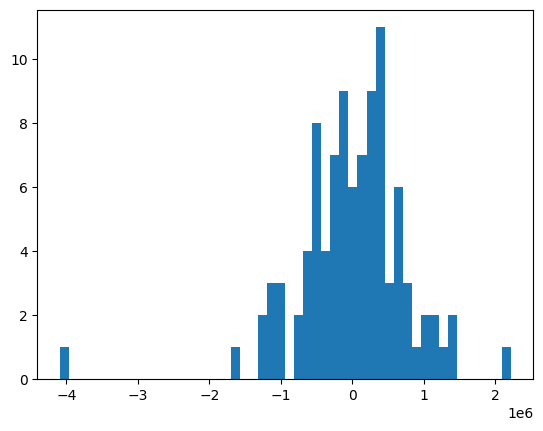

In [45]:
plt.hist(test_predictions - y_test, bins=50);

In [35]:
test = train.iloc[y_test.index]
thr = 1.0 * 10**6
test[np.array(test_predictions - y_test) > thr]

,Имя,Ссылка,Цена,Адрес,Описание,Общая площадь,Площадь кухни,Этаж,Год постройки,Тип жилья,...,Количество лифтов,Газоснабжение,Размер доли,Количество комнат,Область,Город,Район,Улица,Номер дома,Корпус
365,"3-комн. квартира, 80 м², 2/3 этаж",https://kemerovo.cian.ru/sale/flat/312189720/,1800000.0,"Кемеровская область, Прокопьевск, р-н Централь...","срочная продажа. квартира теплая, сухая. рядом...",80.0,9.0,2,1958.0,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Центральный,Международная ул.,2.0,
311,"4-комн. квартира, 60 м², 2/5 этаж",https://kemerovo.cian.ru/sale/flat/309600619/,3350000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Продается уютная четырехкомнатная квартира в г...,60.0,6.0,2,1971.0,Вторичка,...,NaN,NaN,NaN,4,Кемеровская область,Прокопьевск,р-н Рудничный,Институтская ул.,86.0,
154,"3-комн. квартира, 64 м², 9/9 этаж",https://kemerovo.cian.ru/sale/flat/314610774/,4700000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Предлагается к продаже теплая, светлая, чистая...",64.0,9.0,9,1976.0,Вторичка,...,1 пассажирский,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Обручева,41.0,
411,"1/2 квартиры, 52,4 м², 5/5 этаж",https://kemerovo.cian.ru/sale/flat/312255613/,700000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Квартира улучшенной планировки.Рядом школа маг...,52.4,8.8,5,1991.0,Вторичка,...,NaN,NaN,1/2,1,Кемеровская область,Прокопьевск,р-н Центральный,Транспортная ул.,30.0,
211,"3-комн. квартира, 58,1 м², 2/5 этаж",https://kemerovo.cian.ru/sale/flat/314021624/,4100000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Просторная, теплая квартира в новом доме. Квар...",58.1,22.0,2,2016.0,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Яворского,1.0,А
126,"3-комн. квартира, 76,8 м², 2/3 этаж",https://kemerovo.cian.ru/sale/flat/314224900/,1900000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Прекрасная возможность стать владельцем 3-комн...,76.8,9.0,2,1958.0,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Центральный,Международная ул.,2.0,
101,"3-комн. квартира, 52,1 м², 1/2 этаж",https://kemerovo.cian.ru/sale/flat/311415711/,1500000.0,"Кемеровская область, Прокопьевск, р-н Зенковск...",Назовите при звонке данный номер объявления - ...,52.1,7.2,1,NaN,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Зенковский,ул. Олега Кошевого,19.0,Б
56,"2-комн. квартира, 49,8 м², 2/5 этаж",https://kemerovo.cian.ru/sale/flat/310671316/,2600000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Федеральная компания ""Этажи"" предлагает к поку...",49.8,9.4,2,1983.0,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Рудничный,Институтская ул.,109.0,/2


In [36]:
test[np.array(test_predictions - y_test) < -thr]

,Имя,Ссылка,Цена,Адрес,Описание,Общая площадь,Площадь кухни,Этаж,Год постройки,Тип жилья,...,Количество лифтов,Газоснабжение,Размер доли,Количество комнат,Область,Город,Район,Улица,Номер дома,Корпус
68,"2-комн. квартира, 53,4 м², 2/3 этаж",https://kemerovo.cian.ru/sale/flat/309352249/,2900000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Предлагается к продаже двухкомнатная квартира ...,53.4,8.0,2,1958.0,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Центральный,Союзная ул.,9.0,
434,"3-комн. квартира, 64 м², 3/5 этаж",https://kemerovo.cian.ru/sale/flat/308826005/,5700000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Агентство Недвижимости СОЮЗ ПЛЮС\nПокупайте: 3...,64.0,9.0,3,NaN,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Рудничный,"Тырган микрорайон, 10-й микрорайон",2.0,
442,"2-комн. квартира, 52,2 м², 2/5 этаж",https://kemerovo.cian.ru/sale/flat/310392155/,6000000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Агентство Недвижимости СОЮЗ ПЛЮС\nПокупайте: 2...,52.2,9.0,2,1980.0,Вторичка,...,1 пассажирский,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Обручева,49.0,
441,"5-комн. квартира, 95,3 м², 6/9 этаж",https://kemerovo.cian.ru/sale/flat/294254976/,6000000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Агентство недвижимости СОЮЗ ПЛЮС\nПОКУПАЙТЕ: 5...,95.3,NaN,6,1982.0,Вторичка,...,1 пассажирский,NaN,NaN,5,Кемеровская область,Прокопьевск,р-н Рудничный,просп. Строителей,17.0,
481,"3-комн. квартира, 73 м², 4/5 этаж",https://kemerovo.cian.ru/sale/flat/314442290/,6000000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Продаётся 3-х комнатная квартира на Ясной поля...,73.0,8.1,4,2000.0,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Центральный,Латвийская ул.,28.0,А
470,"2-комн. квартира, 41,8 м², 2/5 этаж",https://kemerovo.cian.ru/sale/flat/313467913/,3000000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Продам двухкомнатную квартиру.Пластиковые окна...,41.8,6.0,2,1965.0,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Центральный,ул. Кучина,22.0,
484,"4-комн. квартира, 90 м², 10/10 этаж",https://kemerovo.cian.ru/sale/flat/314168362/,9800000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",продам уютную теплую квартиру. с капитальным р...,90.0,9.0,10,NaN,Вторичка,...,1 пассажирский,NaN,NaN,4,Кемеровская область,Прокопьевск,р-н Рудничный,"Тырган микрорайон, 10-й микрорайон",11.0,
253,"3-комн. квартира, 74,7 м², 1/5 этаж",https://kemerovo.cian.ru/sale/flat/297740224/,5000000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Агентство недвижимости СОЮЗ ПЛЮС \nПокупайте: ...,74.7,NaN,1,2023.0,Вторичка,...,NaN,NaN,NaN,3,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Надежды Крупской,15.0,
429,"2-комн. квартира, 52,2 м², 2/5 этаж",https://kemerovo.cian.ru/sale/flat/305569054/,5500000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Агентство Недвижимости СОЮЗ ПЛЮС\nПокупайте: 2...,52.2,9.0,2,1980.0,Вторичка,...,NaN,NaN,NaN,2,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Обручева,49.0,


In [37]:
X_test

,Общая площадь,Площадь кухни,Этаж,Высота потолков,Год постройки,Номер дома,Подъезды,Количество комнат,Санузел_target_mean,Вид из окон_target_mean,Ремонт_target_mean,Строительная серия_target_mean,Тип дома_target_mean,Тип перекрытий_target_mean,Балкон/лоджия_target_mean,Район_target_mean
72,61.9,9.0,2,NaN,2000.0,9.0,2.0,3,3.868845e+06,3.246009e+06,2.798719e+06,2.961683e+06,2.951730e+06,NaN,2.879369e+06,3.876601e+06
244,76.3,5.0,2,NaN,1986.0,58.0,8.0,4,3.342871e+06,3.246009e+06,3.391500e+06,4.742909e+06,4.233350e+06,3.470397e+06,5.057000e+06,3.876601e+06
437,76.0,9.0,9,NaN,1986.0,49.0,6.0,4,3.868845e+06,4.304095e+06,3.391500e+06,4.742909e+06,4.233350e+06,3.470397e+06,5.057000e+06,3.876601e+06
79,45.0,6.0,5,NaN,1968.0,8.0,6.0,2,3.868845e+06,3.246009e+06,3.391500e+06,3.082531e+06,2.951730e+06,3.470397e+06,3.549835e+06,3.876601e+06
402,61.9,6.0,2,2.4,1984.0,45.0,9.0,3,3.868845e+06,4.304095e+06,3.391500e+06,3.617073e+06,4.233350e+06,3.470397e+06,3.549835e+06,2.563368e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,59.0,8.0,1,NaN,1962.0,16.0,2.0,2,3.868845e+06,3.246009e+06,3.023928e+06,2.961683e+06,2.951730e+06,3.470397e+06,2.879369e+06,2.563368e+06
227,81.2,NaN,3,NaN,1973.0,44.0,3.0,3,2.965321e+06,4.304095e+06,4.900000e+06,3.082531e+06,2.951730e+06,2.992222e+06,3.549835e+06,2.563368e+06
324,60.0,NaN,1,NaN,1967.0,14.0,4.0,4,2.965321e+06,3.287403e+06,3.391500e+06,3.082531e+06,2.951730e+06,3.470397e+06,2.879369e+06,3.876601e+06
398,60.0,6.0,4,2.5,1978.0,3.0,2.0,3,3.868845e+06,2.919015e+06,2.798719e+06,3.617073e+06,4.233350e+06,3.470397e+06,3.549835e+06,3.876601e+06


In [43]:
inference = pd.DataFrame([{
    'Общая площадь': 52.1,
    'Площадь кухни': 9.5,
    'Этаж': 5,
    'Высота потолков': 2.7,
    'Год постройки': 1979,
    'Номер дома': 50,
    'Подъезды': 6,
    'Количество комнат': 2,
    'Санузел': '1 раздельный',
    'Вид из окон': 'На улицу и двор',
    'Ремонт': 'Без ремонта',
    'Строительная серия': '111-97',
    'Тип дома': 'Панельный',
    'Тип перекрытий': 'Железобетонные',
    'Балкон/лоджия': '1 балкон',
    'Район': 'р-н Рудничный'
}])
print(inference)

for col in cat_columns:
    inference = encoder.transform(inference, col)

tuned_model.predict(np.array(inference[best_features]))

   Общая площадь  Площадь кухни  Этаж  Высота потолков  Год постройки  \
0           52.1            9.5     5              2.7           1979   

   Номер дома  Подъезды  Количество комнат       Санузел      Вид из окон  \
0          50         6                  2  1 раздельный  На улицу и двор   

        Ремонт Строительная серия   Тип дома  Тип перекрытий Балкон/лоджия  \
0  Без ремонта             111-97  Панельный  Железобетонные      1 балкон   

           Район  
0  р-н Рудничный  


array([3987540.5], dtype=float32)